In [1]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
cases = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv')
deaths = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_US.csv')
print (cases.head())
print (deaths.head())

        UID iso2 iso3  code3    FIPS   Admin2 Province_State Country_Region  \
0  84001001   US  USA    840  1001.0  Autauga        Alabama             US   
1  84001003   US  USA    840  1003.0  Baldwin        Alabama             US   
2  84001005   US  USA    840  1005.0  Barbour        Alabama             US   
3  84001007   US  USA    840  1007.0     Bibb        Alabama             US   
4  84001009   US  USA    840  1009.0   Blount        Alabama             US   

         Lat      Long_  ... 2/28/23  3/1/23  3/2/23  3/3/23  3/4/23  3/5/23  \
0  32.539527 -86.644082  ...   19732   19759   19759   19759   19759   19759   
1  30.727750 -87.722071  ...   69641   69767   69767   69767   69767   69767   
2  31.868263 -85.387129  ...    7451    7474    7474    7474    7474    7474   
3  32.996421 -87.125115  ...    8067    8087    8087    8087    8087    8087   
4  33.982109 -86.567906  ...   18616   18673   18673   18673   18673   18673   

   3/6/23  3/7/23  3/8/23  3/9/23  
0   1975

In [2]:
cases_ca = cases[cases["Province_State"] == "California"]

In [3]:
cases_idx= cases_ca.set_index("Admin2").T
print(cases_idx.head())

Admin2   Alameda    Alpine    Amador     Butte Calaveras    Colusa  \
UID     84006001  84006003  84006005  84006007  84006009  84006011   
iso2          US        US        US        US        US        US   
iso3         USA       USA       USA       USA       USA       USA   
code3        840       840       840       840       840       840   
FIPS      6001.0    6003.0    6005.0    6007.0    6009.0    6011.0   

Admin2 Contra Costa Del Norte El Dorado    Fresno  ... Stanislaus    Sutter  \
UID        84006013  84006015  84006017  84006019  ...   84006099  84006101   
iso2             US        US        US        US  ...         US        US   
iso3            USA       USA       USA       USA  ...        USA       USA   
code3           840       840       840       840  ...        840       840   
FIPS         6013.0    6015.0    6017.0    6019.0  ...     6099.0    6101.0   

Admin2    Tehama   Trinity    Tulare  Tuolumne Unassigned   Ventura      Yolo  \
UID     84006103  84006

In [4]:
cases_clean = cases_idx.drop(['UID','iso2','iso3','code3','FIPS','Province_State','Country_Region','Lat','Long_','Combined_Key'])
deaths_clean = deaths[deaths["Province_State"] == "California"].set_index("Admin2").T.drop(['UID','iso2','iso3','code3','FIPS','Province_State','Country_Region','Lat','Long_','Combined_Key']).drop("Population",axis=0)

Text(0.5, 1.0, 'cases')

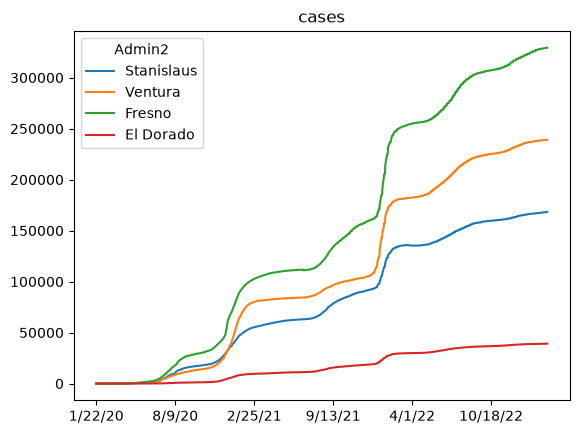

In [5]:
counties =['Stanislaus','Ventura','Fresno','El Dorado' ]
plot= cases_clean[counties].plot()
plot.set_title("cases")

Text(0.5, 1.0, 'deaths')

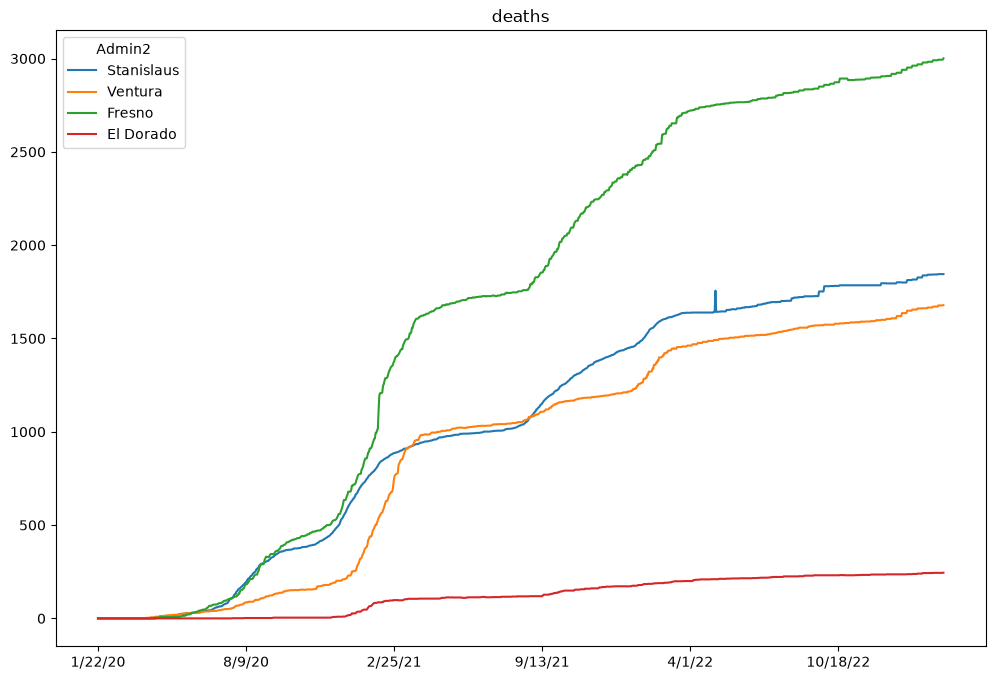

In [6]:
plot=deaths_clean[counties].plot(figsize=(12,8))
plot.set_title("deaths")

In [7]:
cases_diff = cases_clean.diff().rolling(window=7).mean()
deaths_diff = deaths_clean.diff().rolling(window=7).mean()
pop = pd.read_csv('https://gist.githubusercontent.com/NillsF/7923a8c7f27ca98ec75b7e1529f259bb/raw/3bedefbe2e242addba3fb47cbcd239fbed16cd54/california.csv')
pop["CTYNAME"] = pop["CTYNAME"].str.replace(" County", "")
pop

,CTYNAME,Pop,GrowthRate
0,Los Angeles,10105518,2.8820
1,San Diego,3343364,7.7356
2,Orange,3185968,5.6160
3,Riverside,2450758,11.3145
4,San Bernardino,2171603,6.4037
5,Santa Clara,1937570,8.4818
6,Alameda,1666753,10.1590
7,Sacramento,1540975,8.4114
8,Contra Costa,1150215,9.2780
9,Fresno,994400,6.6881


In [8]:
pop2 = pop.drop('GrowthRate', axis=1).set_index('CTYNAME')
pop2


,Pop
CTYNAME,
Los Angeles,10105518
San Diego,3343364
Orange,3185968
Riverside,2450758
San Bernardino,2171603
Santa Clara,1937570
Alameda,1666753
Sacramento,1540975
Contra Costa,1150215


Text(0.5, 1.0, 'avg 7 day cases ')

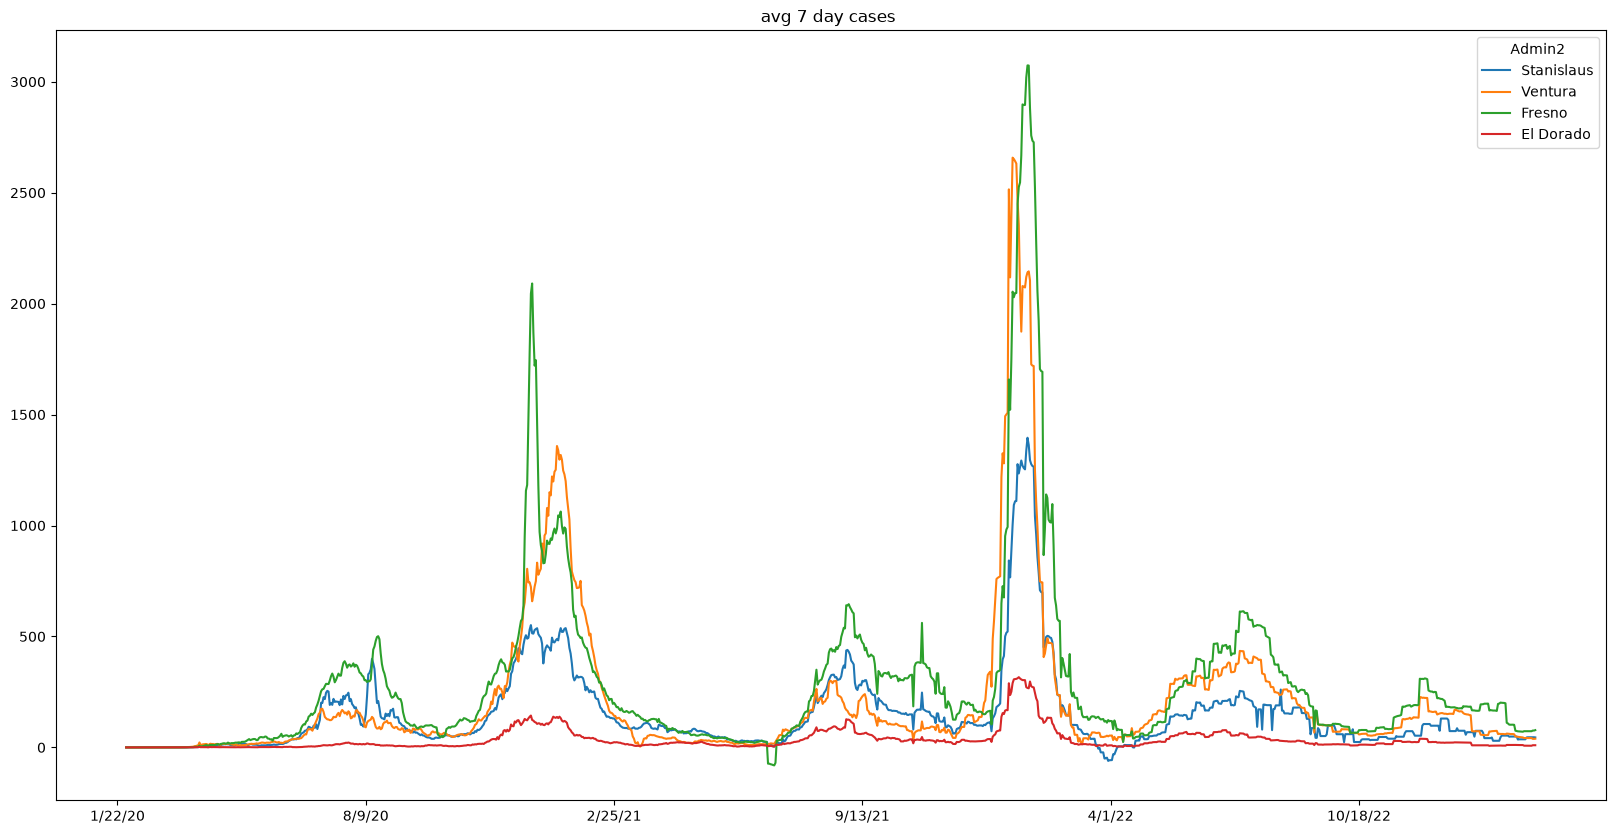

In [9]:
cases_pm = cases_clean.copy()
for c in pop2.index.tolist():
    cases_pm[c] = cases_pm[c]/pop2.loc[c , : ]['Pop']
cases_pm = cases_pm*1000000

deaths_pm = deaths_clean.copy()
for c in pop2.index.tolist():
    deaths_pm[c] = deaths_pm[c]/pop2.loc[c , : ]['Pop']
deaths_pm = deaths_pm*1000000
cases_pm_diff = cases_pm.diff().rolling(window=7).mean()
deaths_pm_diff = deaths_pm.diff().rolling(window=7).mean()
plot = cases_diff[counties].plot(figsize=(20,10))
plot.set_title("avg 7 day cases ")

Text(0.5, 1.0, 'new 7 day avg ')

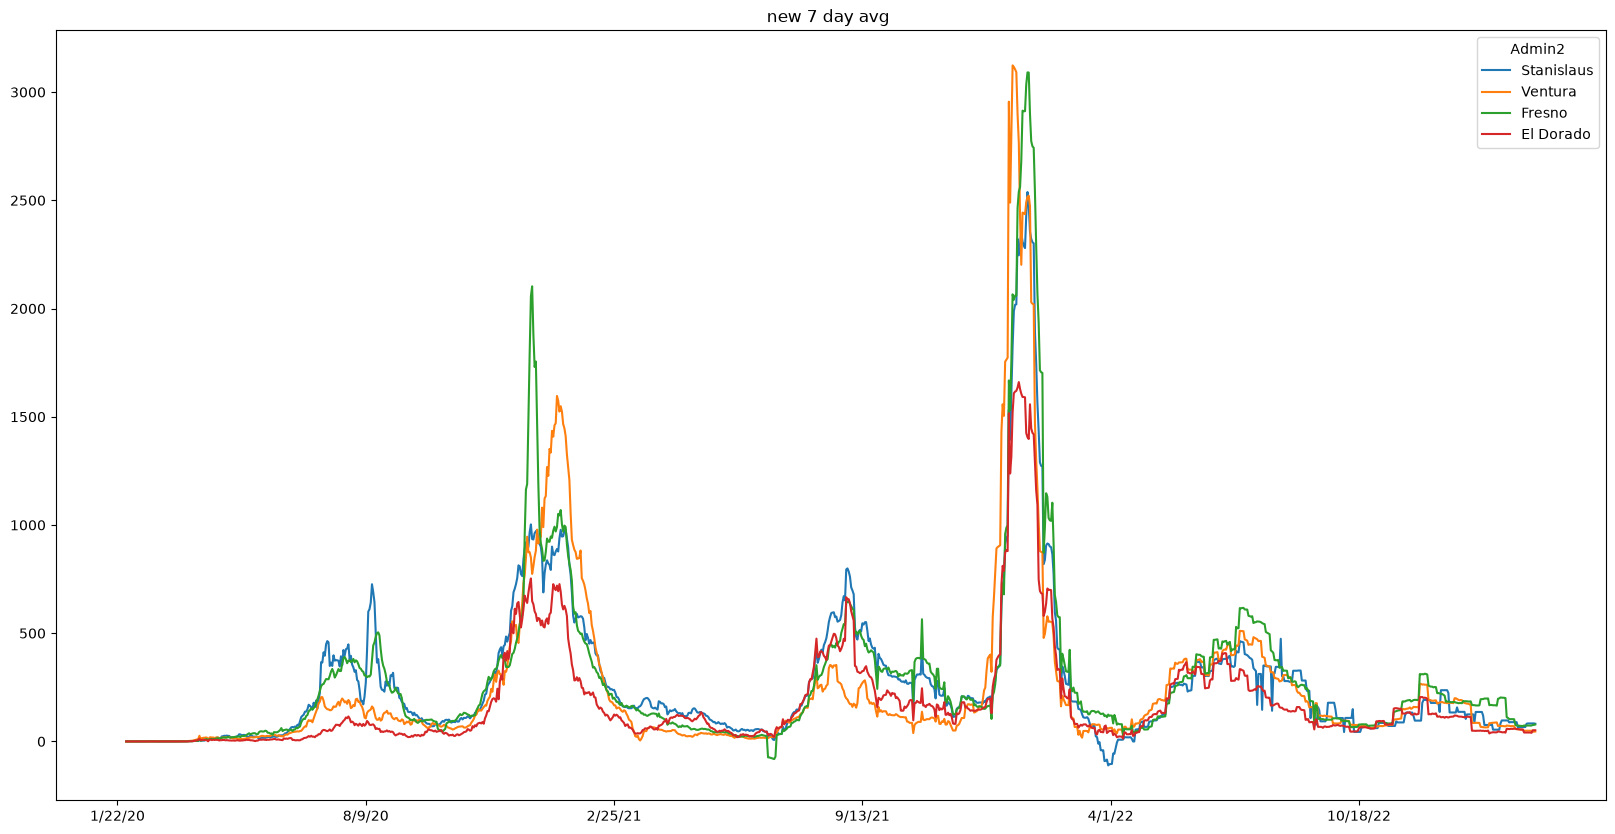

In [10]:
plot = cases_pm_diff[counties].plot(figsize=(20,10))
plot.set_title("new 7 day avg ")

Text(0.5, 1.0, 'Top 10 counties')

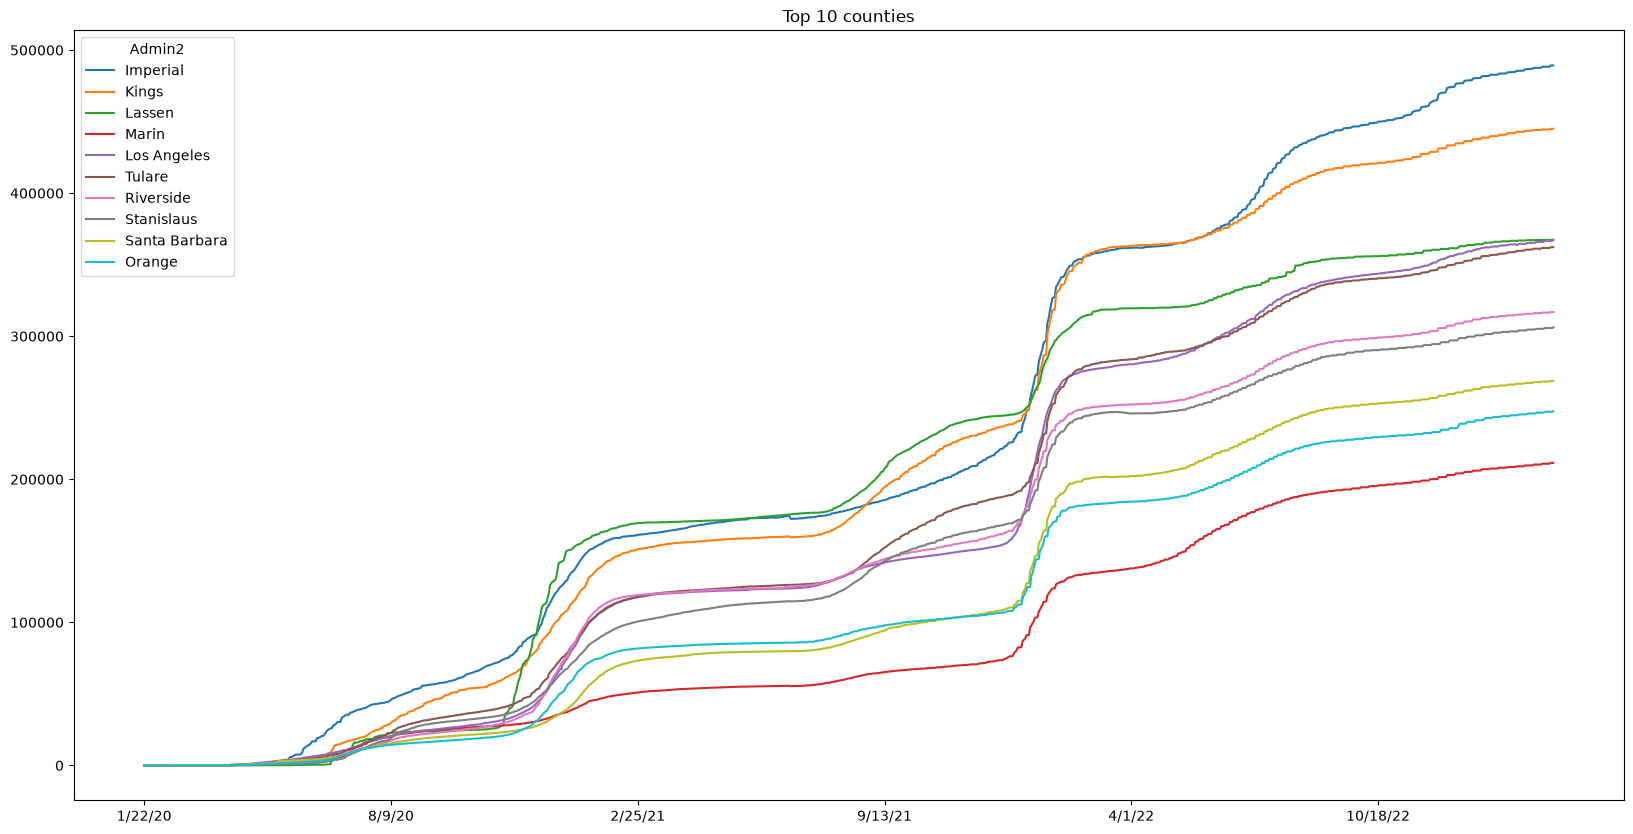

In [11]:
plot = cases_pm.sort_values(axis=1,by='7/20/20',ascending=False).iloc[: , : 10].plot(figsize=(20,10))
plot.set_title("Top 10 counties")



Text(0.5, 1.0, 'Top 10 counties deaths')

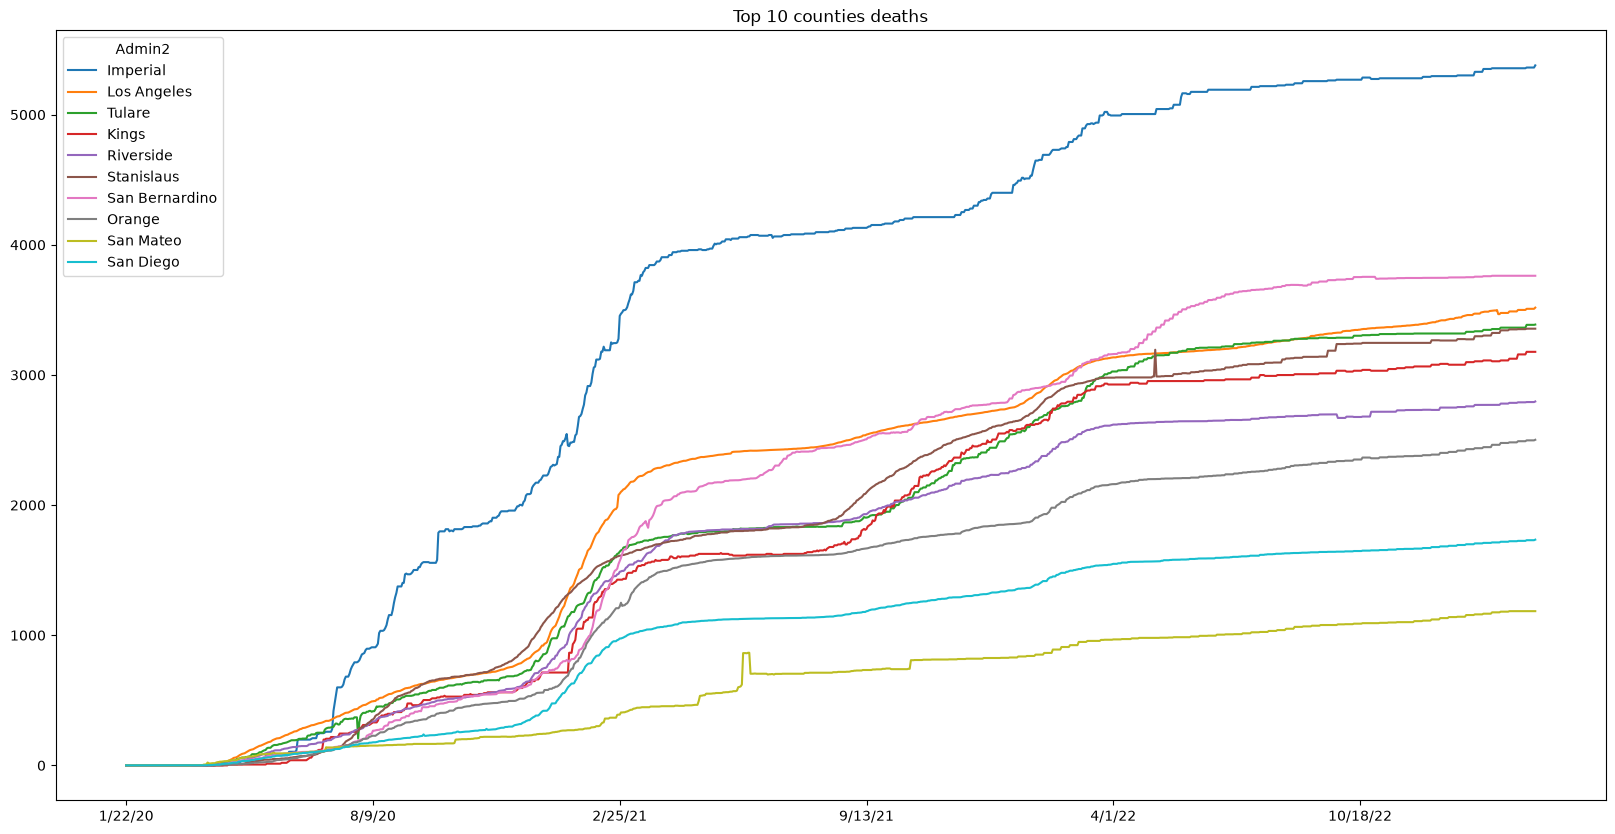

In [12]:
plot = deaths_pm.sort_values(axis=1,by='7/20/20',ascending=False).iloc[: , : 10].plot(figsize=(20,10))
plot.set_title("Top 10 counties deaths")


Text(0.5, 1.0, 'Top 10, 7 day rolling avg cases increases per million')

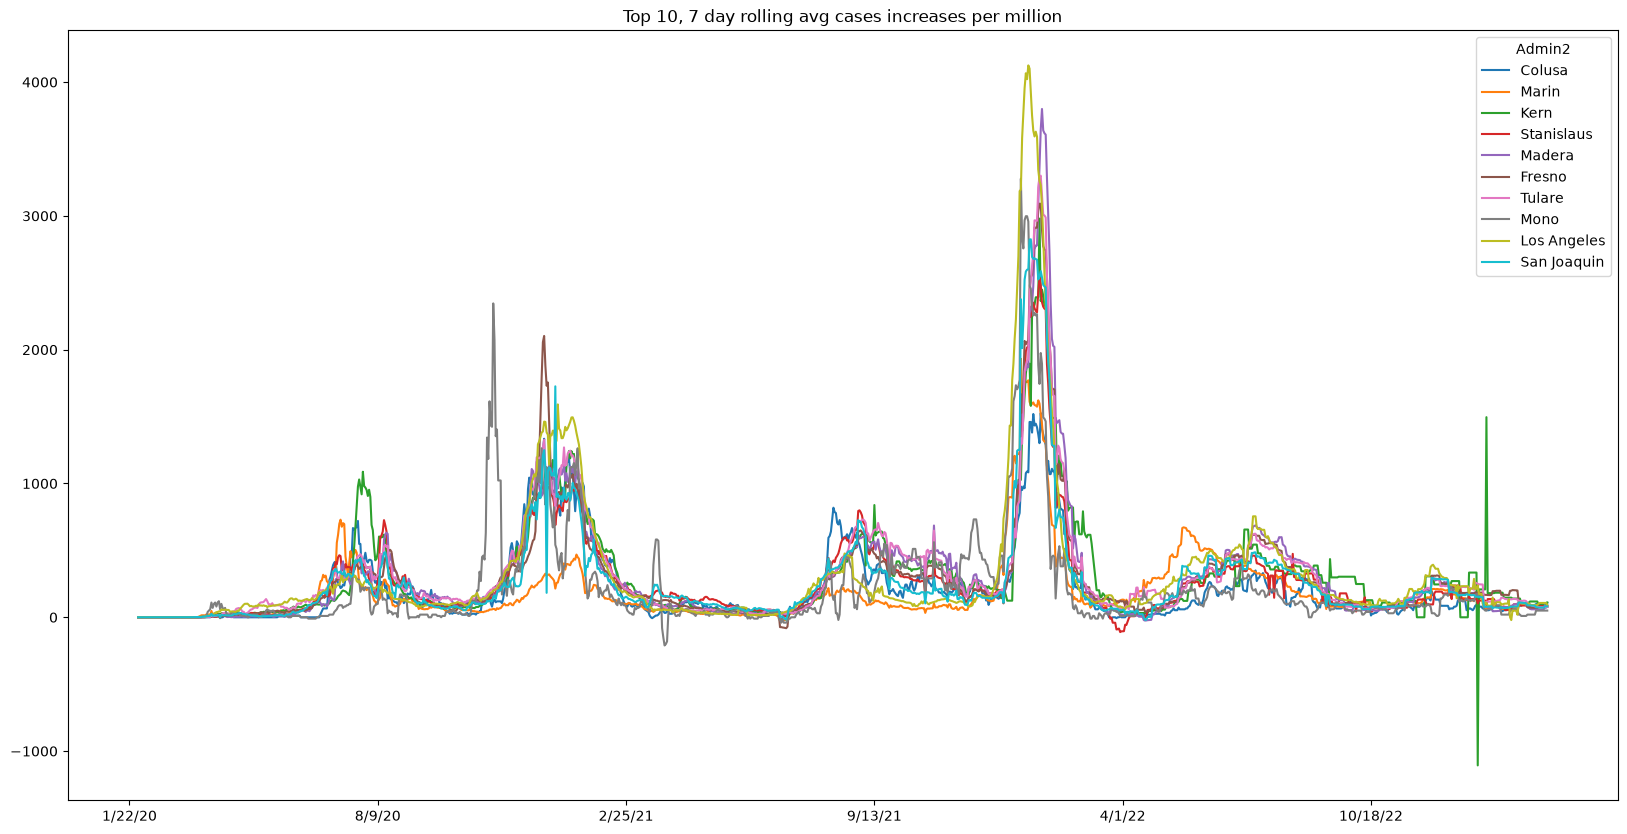

In [13]:
plot = cases_pm_diff.sort_values(axis=1,by='7/20/20',ascending=False).iloc[: , : 10].plot(figsize=(20,10))
plot.set_title("Top 10, 7 day rolling avg cases increases per million")

Text(0.5, 1.0, 'Top 10 counties by 7 day rolling avg daily deaths per million')

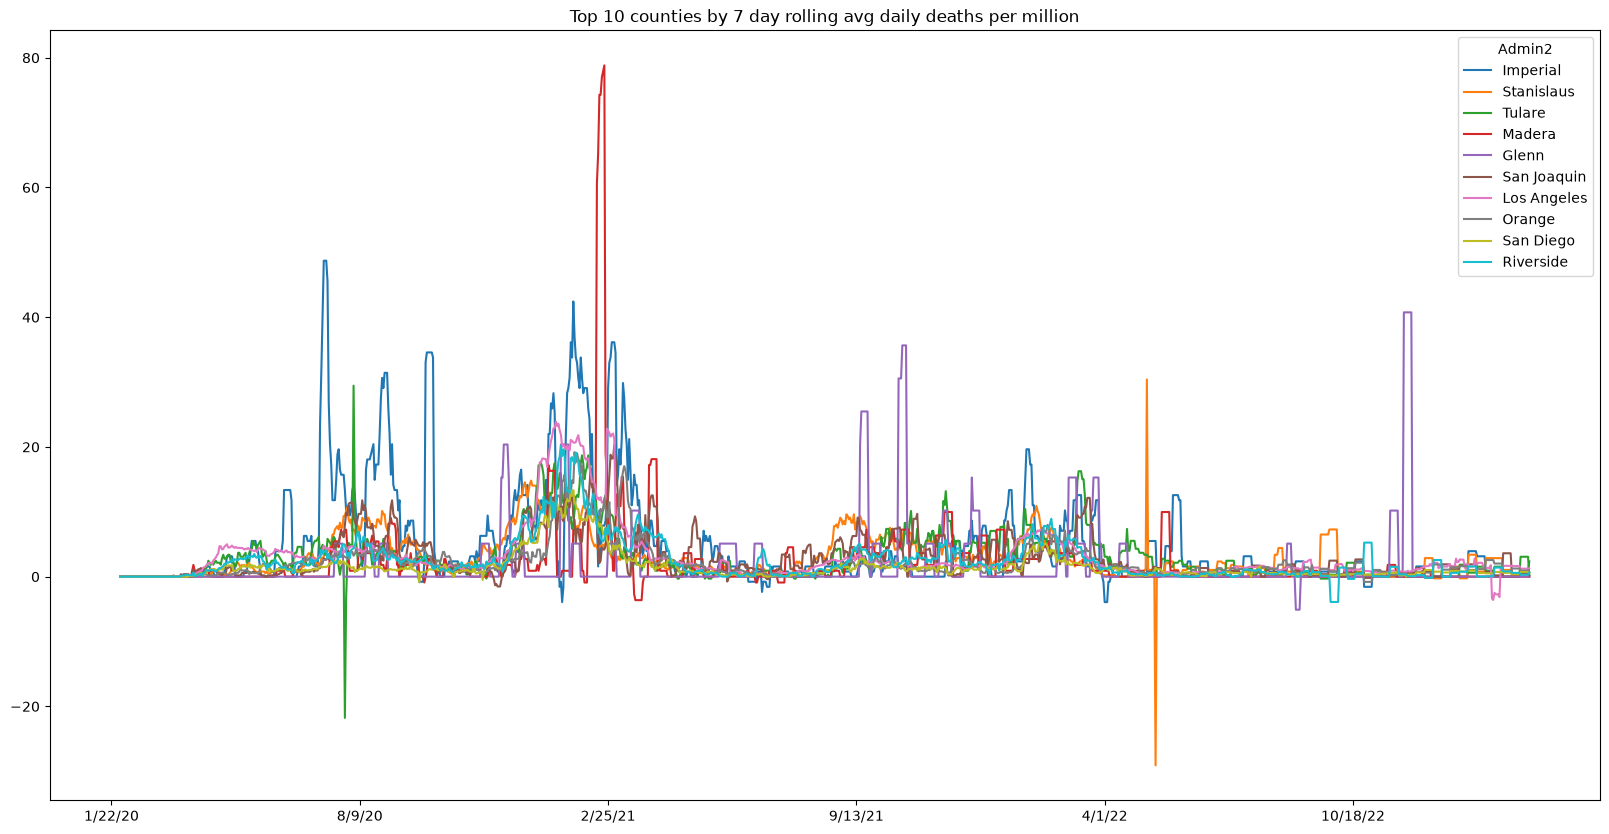

In [14]:
plot = deaths_pm_diff.sort_values(axis=1,by='7/20/20',ascending=False).iloc[: , : 10].plot(figsize=(20,10))
plot.set_title("Top 10 counties by 7 day rolling avg daily deaths per million")